# 06-Deep Learning Notebook 

## Objective
In this notebook we implement deep learning models for multi-horizon forecasting of Ontario Electricity Price (HOEP) 

separate dataset are used for:
- 1-step(one hour) ahead forecasting
- 2-step(two hour) ahead forecasting
- 3-step(three hour) ahead forecasting

each dataset is organized as a sequence of historical observations with a window size of 168, allowing the model to learn short term dependencies, daily patterns and weekly seasonality from the sequence.

the deep learning models considered in this notebook are:
- LSTM
- GRU

For each forcast horizon:
 - the model is trained on the training set
 - hyperparameters are selected using the validation set 
 - the performance is evaluated on the test set

Evaluation metrics:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

To asses the temporal stability the test set is also devided into four chronological segments.


## Imports

In [232]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import random
from pathlib import Path

import torch
import torch.nn as nn 
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import mean_absolute_error, mean_squared_error

import copy 

## Reproducibility and System 

In [233]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Helper Functions

In [234]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

def save_model_artifact(model, model_name, horizon):
    model_path = models_dir / f"{model_name}_h{horizon}.pt"
    state_dict = {key: value.detach().cpu() for key, value in model.state_dict().items()}
    torch.save(state_dict, model_path)
    return model_path

def evaluate( y_true, y_pred):
    mse = mean_absolute_error(y_true, y_pred)
    mae = np.sqrt(mean_squared_error(y_true, y_pred))
    return mse, mae

def evaluate_by_chunk(y_true, y_pred, model_name, horizon, n_chunks=4):
    y_true_chunks = np.array_split(np.asarray(y_true), n_chunks)
    y_pred_chunks = np.array_split(np.asarray(y_pred), n_chunks)

    rows = []
    for i, (true_chunk, pred_chunk) in enumerate(zip(y_true_chunks, y_pred_chunks), start=1):
        mae, rmse = evaluate(true_chunk, pred_chunk)
        rows.append({
            "model": model_name,
            "horizon": horizon,
            "test_chunk": i,
            "mae": mae,
            "rmse": rmse
        })
    return pd.DataFrame(rows)


def plot_predictions(y_true, preds_dict, horizon, start_idx= None, end_idx=None):
    plt.figure(figsize=(12, 5))
    plt.plot(np.asarray(y_true)[start_idx:end_idx], label="Actual", linewidth=2)

    for model_name, pred in preds_dict.items():
        plt.plot(np.asarray(pred)[start_idx:end_idx], label=model_name, alpha=0.8)

    plt.title(f"Forecast vs Actual — Horizon {horizon}")
    plt.xlabel("Time Index")
    plt.ylabel("HOEP")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_training_history(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

## Load horizon-specific deep learning datasets
The deep learning datasets are created in notebook number 3 

 Each `X` array has shape :
`(total number of windows (samples), sequence length, number of features)`

and each `y` contains the corresponding target values.



In [235]:
dl_dir = Path.cwd().parent / "data/processed/dl_dir"

def load_dl_data(h):
    X_train = np.load(dl_dir / f"X_train_h{h}.npy")
    y_train = np.load(dl_dir / f"y_train_h{h}.npy")
    X_val = np.load(dl_dir / f"X_val_h{h}.npy")
    y_val = np.load(dl_dir / f"y_val_h{h}.npy")
    X_test = np.load(dl_dir / f"X_test_h{h}.npy")
    y_test = np.load(dl_dir / f"y_test_h{h}.npy")
    
    return X_train, y_train, X_val, y_val, X_test, y_test

## PyTorch Dataset and DataLoader

To train a recurrent neural network in PyTorch, raw numpy arrays must first be converted into PyTorch tensors, the native data format that PyTorch uses for all computations, gradient tracking, and GPU operations.
Once converted, the tensors are wrapped in a `SequenceDataset` object, which keeps `X` and` y` permanently paired so they never get misaligned during training.
Finally, the dataset is passed to a `DataLoader`, which handles batching and shuffling automatically, feeding the model one batch at a time during training while keeping validation and test sets in chronological order.

In [236]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [237]:
def make_loader(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=32):
    train_dataset = SequenceDataset(X_train, y_train)
    val_dataset = SequenceDataset(X_val, y_val)
    test_dataset = SequenceDataset(X_test, y_test)  

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader
    

## Model Architectures

Two recurrent neural network architectures are used:

- LSTM
- GRU

Both models take as input a sequence of 168 hourly observations and output a single forecast value.

In [238]:
class LstmRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()

        effective_dropout = 0.0 if num_layers == 1 else dropout

        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True,
            dropout = effective_dropout,
        )

        self.dropout = nn.Dropout(effective_dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward (self, x):
            out, _ = self.lstm(x)
            out = out[:,-1,:]
            out = self.dropout(out)
            out = self.fc(out)
            return out





## Training and prediction utilities

In [239]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch, y_batch =  X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def evaluate_loss(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

def train_model(model, train_loader, val_loader, epochs = 100, learning_rate = 0.01, patience = 5, device = device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    history = {
        "train_loss": [],
        "val_loss": []
    }


    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())


        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

    model.load_state_dict(best_state)
    return model, history, best_val_loss


def predict_model(model, test_loader, device):

    model.eval()
    preds=[]

    with torch.no_grad():
        
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds.extend(outputs.cpu().numpy().flatten())

    return np.array(preds)

        






        



## LSTM Hyperparameter Tuning

For each forecast horizon, several LSTM configurations are evaluated using the validation set.

The best configuration is selected based on validation RMSE.

In [240]:
lstm_param_grid = [
    {
        "hidden_size": 64,
        "num_layers": 1,
        "dropout": 0.2,
        "learning_rate": 0.01,
        "batch_size": 32,
        "patience": 10,
        "epochs": 200
    }
  
]

In [241]:

import joblib
PROJECT_ROOT = Path.cwd().parent
artifacts_dir = PROJECT_ROOT / "artifacts"/"scalers"
scaler_y = joblib.load(artifacts_dir / "scaler_y.pkl")
lstm_results = []
lstm_weekly_rows = []
lstm_histories = {}
lstm_best_configs = {}
lstm_models = {}




for h in [1,2,3]:
    X_train, y_train, X_val, y_val, X_test, y_test = load_dl_data(h)
    best_rmse = float("inf")   
    best_cfg     = None
    best_history = None
    best_model   = None


    for cfg in lstm_param_grid:
        train_loader, val_loader, test_loader = make_loader(X_train, y_train, X_val, y_val,
                                                             X_test, y_test, batch_size=cfg["batch_size"])
        model = LstmRegressor(input_size=X_train.shape[2], hidden_size=cfg["hidden_size"], 
                            num_layers=cfg["num_layers"], dropout=cfg["dropout"]).to(device)
        
        model, history, _ = train_model (
            model = model,
            train_loader = train_loader,
            val_loader = val_loader,
            epochs = cfg["epochs"],
            learning_rate = cfg["learning_rate"],
            patience = cfg["patience"],
            device = device 
        )

        val_pred = predict_model(model, val_loader, device)
        val_mae, val_rmse = evaluate(y_val, val_pred)

        if val_rmse < best_rmse:
            best_rmse = val_rmse
            best_cfg = cfg
            best_history = history
            best_model = model
        
    lstm_models[h] = best_model    
    lstm_best_configs[h] = best_cfg
    lstm_histories[h] = best_history
    save_model_artifact(best_model, "lstm", h)

    # # Retrain on train + validation
    # X_train_val = np.concatenate([X_train, X_val], axis=0)
    # y_train_val = np.concatenate([y_train, y_val], axis=0)

    # split_idx = int(len(X_train_val) * 0.9)
    # X_train_final, X_val_final = X_train_val[:split_idx], X_train_val[split_idx:]
    # y_train_final, y_val_final = y_train_val[:split_idx], y_train_val[split_idx:]

    # train_loader, val_loader, test_loader = make_loader(
    #     X_train_final, y_train_final, X_val_final, y_val_final, X_test, y_test,
    #     batch_size=best_cfg["batch_size"]
    # )

    # final_model = LstmRegressor(
    #     input_size=X_train.shape[2],
    #     hidden_size=best_cfg["hidden_size"],
    #     num_layers=best_cfg["num_layers"],
    #     dropout=best_cfg["dropout"]
    # ).to(device)

    # final_model, _, _ = train_model(
    #     model=final_model,
    #     train_loader=train_loader,
    #     val_loader=val_loader,
    #     epochs=best_cfg["epochs"],
    #     learning_rate=best_cfg["learning_rate"],
    #     patience=5,
    #     device=device
    # )

    test_pred = predict_model(best_model, test_loader, device=device)
    test_pred_orig = scaler_y.inverse_transform(test_pred.reshape(-1, 1)).flatten()
    y_test_orig    = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    test_mae, test_rmse = evaluate(y_test_orig, test_pred_orig)

    lstm_results.append({
        "model": "LSTM",
        "horizon": h,
        "best_config": str(best_cfg),
        "test_mae": test_mae,
        "test_rmse": test_rmse
    })


    weekly_df = evaluate_by_chunk(y_test_orig, test_pred_orig, "LSTM", h)
    lstm_weekly_rows.append(weekly_df)

lstm_results_df = pd.DataFrame(lstm_results)
lstm_weekly_df = pd.concat(lstm_weekly_rows, ignore_index=True)

lstm_weekly_df


    

Epoch 1/200 - Train Loss: 0.6627 - Val Loss: 5.6941
Epoch 2/200 - Train Loss: 0.6450 - Val Loss: 5.1747
Epoch 3/200 - Train Loss: 0.6319 - Val Loss: 5.2212
Epoch 4/200 - Train Loss: 0.6185 - Val Loss: 5.0220
Epoch 5/200 - Train Loss: 0.6125 - Val Loss: 4.7010
Epoch 6/200 - Train Loss: 0.5958 - Val Loss: 4.6975
Epoch 7/200 - Train Loss: 0.5738 - Val Loss: 5.0030
Epoch 8/200 - Train Loss: 0.5682 - Val Loss: 4.5886
Epoch 9/200 - Train Loss: 0.5518 - Val Loss: 4.7608
Epoch 10/200 - Train Loss: 0.5413 - Val Loss: 4.9504
Epoch 11/200 - Train Loss: 0.5652 - Val Loss: 5.0969
Epoch 12/200 - Train Loss: 0.5299 - Val Loss: 5.2787
Epoch 13/200 - Train Loss: 0.5186 - Val Loss: 5.2484
Epoch 14/200 - Train Loss: 0.5103 - Val Loss: 5.4987
Epoch 15/200 - Train Loss: 0.5153 - Val Loss: 5.4200
Epoch 16/200 - Train Loss: 0.5081 - Val Loss: 5.9639
Epoch 17/200 - Train Loss: 0.4786 - Val Loss: 5.0519
Epoch 18/200 - Train Loss: 0.4836 - Val Loss: 5.5519
Early stopping triggered
Epoch 1/200 - Train Loss: 0.77

,model,horizon,test_chunk,mae,rmse
0,LSTM,1,1,21.174485,52.065608
1,LSTM,1,2,11.939880,25.870822
2,LSTM,1,3,10.545187,25.856675
3,LSTM,1,4,6.985556,13.843716
4,LSTM,2,1,27.949479,59.889931
5,LSTM,2,2,18.085230,34.275889
6,LSTM,2,3,12.464889,28.946212
7,LSTM,2,4,9.980796,17.344528
8,LSTM,3,1,27.972850,59.265203
9,LSTM,3,2,16.503888,32.913809


## Plot LSTM training histories

Best config for horizon 1: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.01, 'batch_size': 32, 'patience': 10, 'epochs': 200}


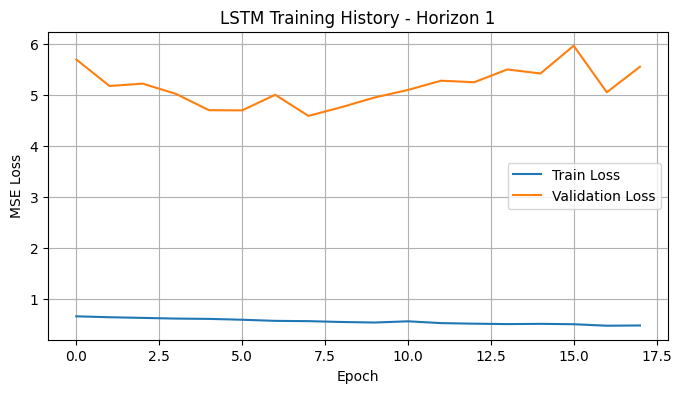

Best config for horizon 2: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.01, 'batch_size': 32, 'patience': 10, 'epochs': 200}


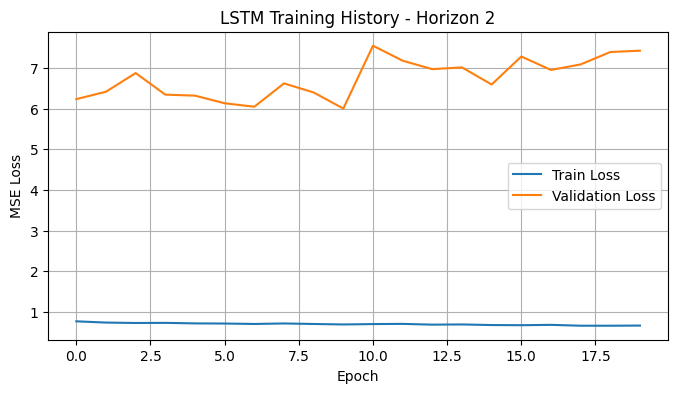

Best config for horizon 3: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.01, 'batch_size': 32, 'patience': 10, 'epochs': 200}


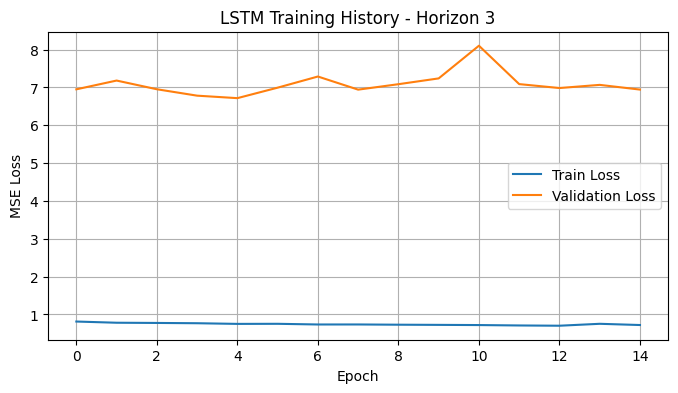

In [242]:
for h in [1,2,3]:
    print(f"Best config for horizon {h}: {lstm_best_configs[h]}")
    plot_training_history(lstm_histories[h], title=f"LSTM Training History - Horizon {h}")

## Prediction Plots

The following plots compare actual test values with the predictions from the deep learning models.

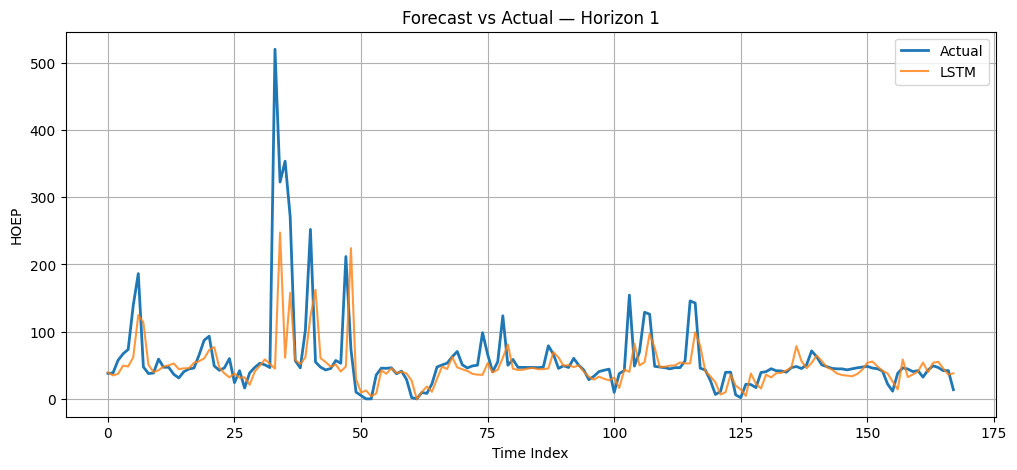

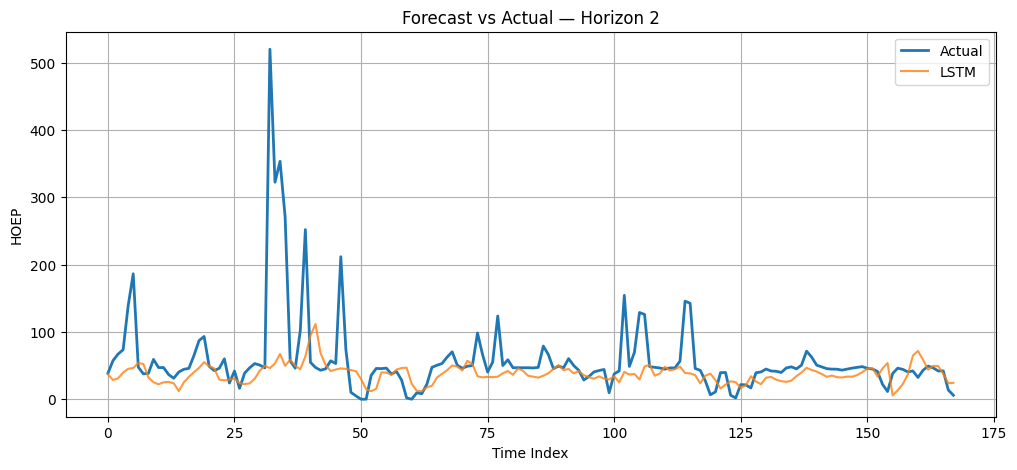

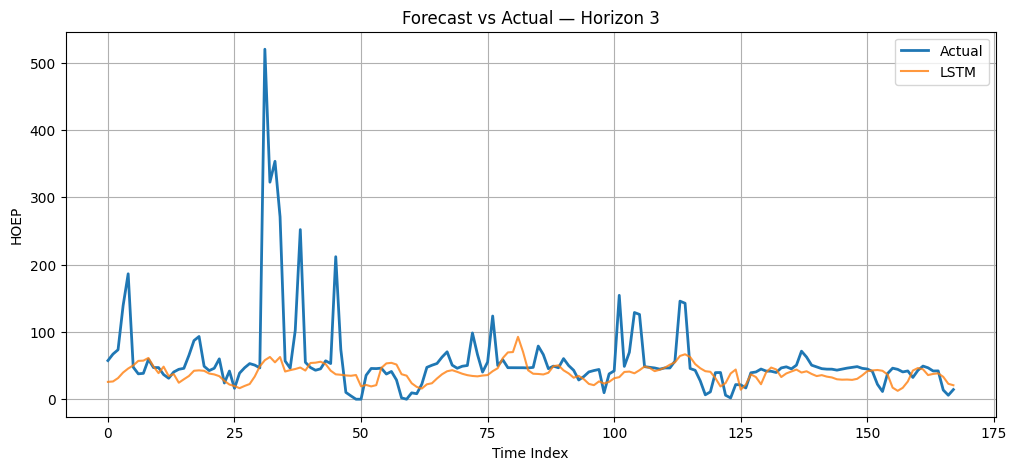

In [247]:
lstm_pred ={}
for h in [1,2,3]:
    X_train, y_train, X_val, y_val, X_test, y_test = load_dl_data(h)

    _, _, test_loader = make_loader(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=64)

    lstm_pred_h= predict_model(lstm_models[h], test_loader, device=device)
    lstm_pred[h] = scaler_y.inverse_transform(lstm_pred_h.reshape(-1, 1)).flatten()
    y_test_orig    = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

    preds_dict = {
        "LSTM": lstm_pred[h]
    }

    plot_predictions(y_test_orig, preds_dict , horizon=h, start_idx=0, end_idx=168)

In [244]:
all_ml_weekly_df = pd.concat([
   lstm_weekly_df
], ignore_index=True)

# Pivot weekly RMSE
all_ml_weekly_df.pivot_table(
    index=["model", "horizon"],
    columns="test_chunk",
    values="rmse"
)

test_chunk             1          2          3          4
model horizon                                            
LSTM  1        52.065608  25.870822  25.856675  13.843716
      2        59.889931  34.275889  28.946212  17.344528
      3        59.265203  32.913809  30.829057  18.679271